# Dimensionality Reduction & Unsupervised Clustering

**Assignment notebook**

## Objective
Standardize numerical features, apply Principal Component Analysis (PCA), inspect explained variance, select a K-Means cluster count using the Elbow Method and Silhouette Score, and compare K-Means, DBSCAN, and Agglomerative (hierarchical) clustering. Visualize cluster assignments in 2D and 3D PCA spaces.

## Dataset
This notebook uses the Iris dataset bundled with scikit-learn (150 observations, four numerical features, three species). Species labels are used only for post-hoc interpretation and are **not** used to fit the clustering algorithms.

## Notes
- PCA and clustering use standardized numerical features.
- Silhouette scores are calculated in standardized feature space.
- DBSCAN noise points have label `-1` and are excluded from its silhouette score.
- The two-dimensional PCA plot is a projection; it may not preserve all high-dimensional structure.

## 1. Install dependencies (run once if needed)

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn plotly scipy

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl (240 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------ --------------------------- 0.8/2.5 MB 5.2 MB/s eta 0:00:01
   ----------------------------- ---------- 1.8/2.5 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 5.0 MB/s  0:00:00
Using cached kiwisolver-1.5.1-cp314


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import libraries and load the dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

iris = load_iris(as_frame=True)
df = iris.data.copy()
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
df["species"] = pd.Series(iris.target).map(dict(enumerate(iris.target_names))).values
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = df[features].copy()

print("Dataset shape:", df.shape)
display(df.head())
display(df[features].describe().round(3))
print("Missing values:")
display(df[features].isna().sum())

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


Missing values:


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64

## 3. Standardize numerical features

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaled_df = pd.DataFrame(X_scaled, columns=features)
print("Standardized means (approximately 0):")
display(scaled_df.mean().round(6))
print("Standardized standard deviations (approximately 1):")
display(scaled_df.std(ddof=0).round(6))

Standardized means (approximately 0):


sepal_length   -0.0
sepal_width    -0.0
petal_length   -0.0
petal_width    -0.0
dtype: float64

Standardized standard deviations (approximately 1):


sepal_length    1.0
sepal_width     1.0
petal_length    1.0
petal_width     1.0
dtype: float64

## 4. PCA and explained variance scree plot

PCA creates components that capture decreasing amounts of variance. The explained variance ratio shows the proportion captured by each component; the cumulative curve helps assess how many components retain a chosen proportion, such as 90%.

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.7296,0.7296
1,PC2,0.2285,0.9581
2,PC3,0.0367,0.9948
3,PC4,0.0052,1.0000


Components needed to explain at least 90% of variance: 2


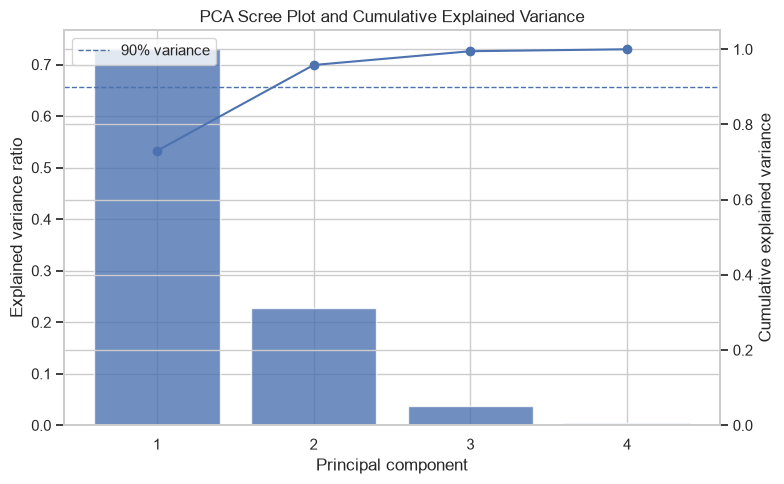

In [5]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_90 = int(np.argmax(cumulative >= 0.90) + 1)

variance_table = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained))],
    "Explained Variance Ratio": explained,
    "Cumulative Explained Variance": cumulative
})
display(variance_table.round(4))
print(f"Components needed to explain at least 90% of variance: {n_90}")

fig, ax1 = plt.subplots(figsize=(8, 5))
pcs = np.arange(1, len(explained) + 1)
ax1.bar(pcs, explained, alpha=0.8)
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_xticks(pcs)
ax2 = ax1.twinx()
ax2.plot(pcs, cumulative, marker="o")
ax2.set_ylabel("Cumulative explained variance")
ax2.axhline(0.90, linestyle="--", linewidth=1, label="90% variance")
ax2.set_ylim(0, 1.05)
ax2.legend()
plt.title("PCA Scree Plot and Cumulative Explained Variance")
fig.tight_layout()
plt.show()

In [10]:
import nbformat
import IPython
import plotly.express as px

print("nbformat version:", nbformat.__version__)
print("IPython version:", IPython.__version__)
print("Plotly is ready!")

nbformat version: 5.11.1
IPython version: 9.16.1
Plotly is ready!


In [7]:
%pip install --upgrade nbformat ipython plotly

Defaulting to user installation because normal site-packages is not writeable
  Using cached nbformat-5.11.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached ipython-9.17.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached fastjsonschema-2.22.2-py3-none-any.whl.metadata (2.1 kB)
Using cached nbformat-5.11.1-py3-none-any.whl (79 kB)
Using cached ipython-9.17.1-py3-none-any.whl (639 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.7 MB 6.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.7 MB 6.3 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.7 MB 7.2 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.7 MB 7.5 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.7 MB 7.0 MB/s eta 0:00:01
   ---------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 5. PCA 2D and 3D projections

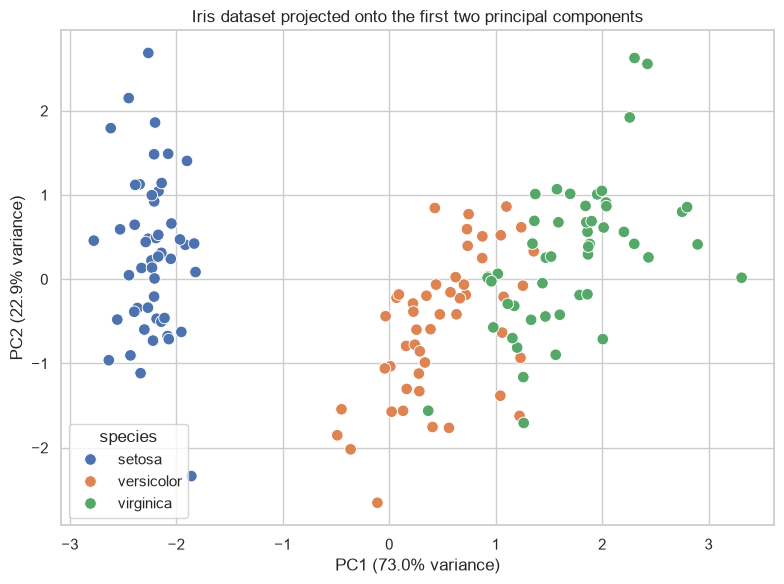

In [12]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)
pca_2_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_2_df["species"] = df["species"].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_2_df, x="PC1", y="PC2", hue="species", s=70)
plt.title("Iris dataset projected onto the first two principal components")
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()

fig = px.scatter_3d(
    pca_3_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="species",
    title="Iris dataset: 3D PCA projection"
)

fig.show(renderer="browser")

## 6. K-Means: Elbow Method and Silhouette Score

The Elbow Method compares within-cluster sum of squares (inertia) across values of k. Silhouette scores range from -1 to 1; higher scores generally indicate better cohesion and separation. Use both diagnostics rather than treating either as a definitive answer.

,k,Inertia,Silhouette Score
0,2,222.3617,0.5818
1,3,139.8205,0.4599
2,4,114.0925,0.3869
3,5,90.9275,0.3459
4,6,81.5444,0.3171
5,7,72.6311,0.3202
6,8,62.5406,0.3387
7,9,55.1195,0.3424
8,10,47.3910,0.3518


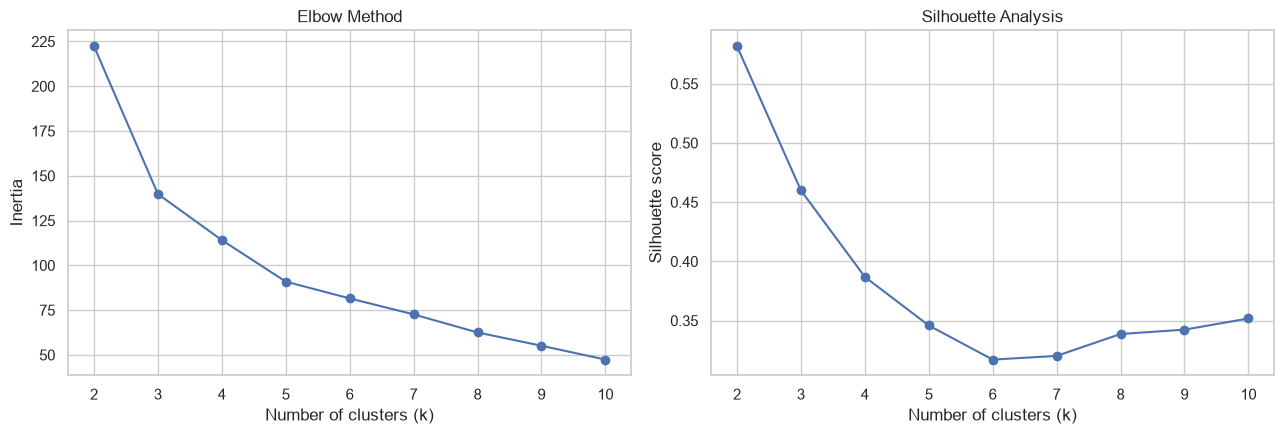

k with highest silhouette score among tested values: 2
Inspect the elbow plot as well; the silhouette maximum is a diagnostic, not an unquestionable answer.


In [13]:
k_values = range(2, 11)
inertias, silhouette_scores = [], []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

metrics_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})
display(metrics_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(metrics_df["k"], metrics_df["Inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[1].plot(metrics_df["k"], metrics_df["Silhouette Score"], marker="o")
axes[1].set_title("Silhouette Analysis")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_xticks(list(k_values))
plt.tight_layout()
plt.show()

best_k_silhouette = int(metrics_df.loc[metrics_df["Silhouette Score"].idxmax(), "k"])
print(f"k with highest silhouette score among tested values: {best_k_silhouette}")
print("Inspect the elbow plot as well; the silhouette maximum is a diagnostic, not an unquestionable answer.")

In [15]:
import plotly.io as pio

pio.renderers.default = "browser"

## 7. K-Means clustering and visualizations

Selected k: 2
K-Means silhouette score: 0.5818


species,setosa,versicolor,virginica,All
kmeans_cluster,,,,
0,0,50,50,100
1,50,0,0,50
All,50,50,50,150


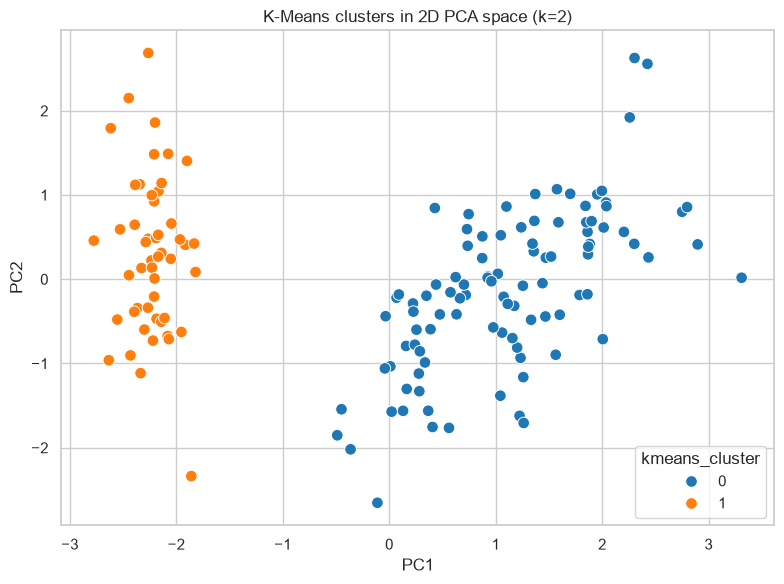

In [16]:
selected_k = best_k_silhouette
kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

results = df.copy()
results["kmeans_cluster"] = kmeans_labels
results["PC1"], results["PC2"] = X_pca_2[:, 0], X_pca_2[:, 1]

print("Selected k:", selected_k)
print("K-Means silhouette score:", round(silhouette_score(X_scaled, kmeans_labels), 4))
display(pd.crosstab(results["kmeans_cluster"], results["species"], margins=True))

plt.figure(figsize=(8, 6))
sns.scatterplot(data=results, x="PC1", y="PC2", hue="kmeans_cluster", palette="tab10", s=70)
plt.title(f"K-Means clusters in 2D PCA space (k={selected_k})")
plt.tight_layout()
plt.show()

kmeans_3d = pca_3_df.copy()
kmeans_3d["cluster"] = kmeans_labels.astype(str)
px.scatter_3d(kmeans_3d, x="PC1", y="PC2", z="PC3", color="cluster",
              title=f"K-Means clusters in 3D PCA space (k={selected_k})").show()

## 8. DBSCAN clustering

DBSCAN groups points in dense regions and labels outliers as noise (`-1`). Its result depends on `eps` and `min_samples`; inspect the k-distance plot and tune parameters if necessary. The values below are an initial example, not universal settings.

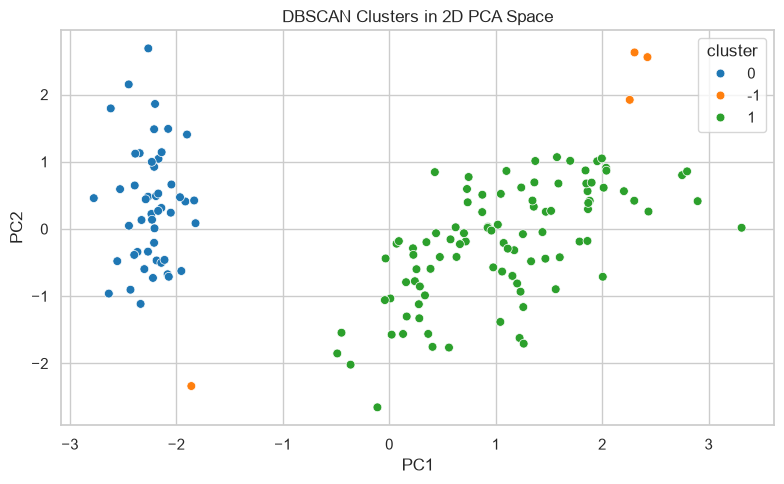

In [22]:
# Prepare DBSCAN results for visualization
dbscan_plot = pca_2_df.copy()
dbscan_plot["cluster"] = dbscan_labels.astype(str)

# Plot DBSCAN clusters
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=dbscan_plot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=40,
    ax=ax
)

ax.set_title("DBSCAN Clusters in 2D PCA Space")
plt.tight_layout()
display(fig)
plt.close(fig)

## 9. Hierarchical (Agglomerative) clustering

Hierarchical cluster count: 2
Hierarchical silhouette score: 0.5770


species,setosa,versicolor,virginica,All
hierarchical_cluster,,,,
0,1,50,50,101
1,49,0,0,49
All,50,50,50,150


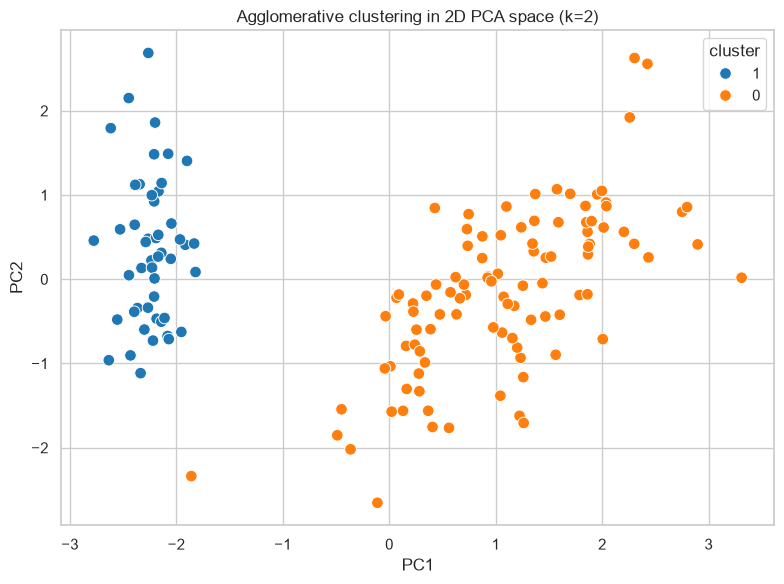

In [18]:
hierarchical = AgglomerativeClustering(n_clusters=selected_k, linkage="ward")
hier_labels = hierarchical.fit_predict(X_scaled)
results["hierarchical_cluster"] = hier_labels
hier_sil = silhouette_score(X_scaled, hier_labels)

print("Hierarchical cluster count:", selected_k)
print(f"Hierarchical silhouette score: {hier_sil:.4f}")
display(pd.crosstab(results["hierarchical_cluster"], results["species"], margins=True))

hier_plot = pca_2_df.copy()
hier_plot["cluster"] = hier_labels.astype(str)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=hier_plot, x="PC1", y="PC2", hue="cluster", palette="tab10", s=70)
plt.title(f"Agglomerative clustering in 2D PCA space (k={selected_k})")
plt.tight_layout()
plt.show()

hier_3d = pca_3_df.copy()
hier_3d["cluster"] = hier_labels.astype(str)
px.scatter_3d(hier_3d, x="PC1", y="PC2", z="PC3", color="cluster",
              title="Agglomerative clusters in 3D PCA space").show()

## 10. Compare clustering algorithms

,Algorithm,Clusters (excluding noise),Noise points,Silhouette score
0,K-Means,2,0,0.5818
1,DBSCAN,2,4,0.5979
2,Agglomerative (Ward),2,0,0.5770


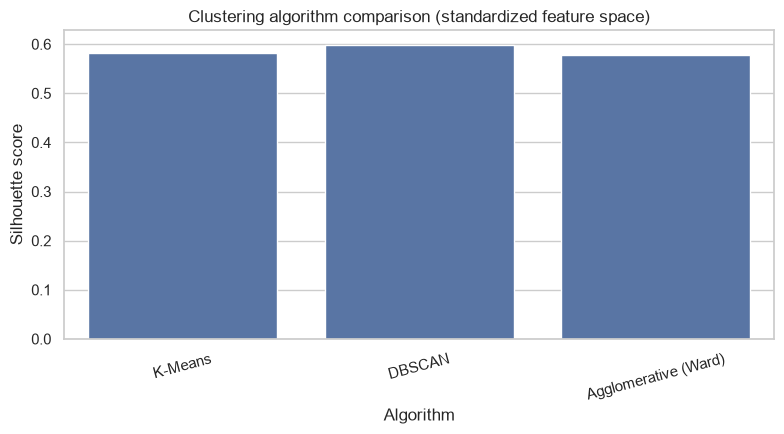

In [19]:
comparison = pd.DataFrame([
    {"Algorithm": "K-Means",
     "Clusters (excluding noise)": len(set(kmeans_labels)),
     "Noise points": 0,
     "Silhouette score": silhouette_score(X_scaled, kmeans_labels)},
    {"Algorithm": "DBSCAN",
     "Clusters (excluding noise)": n_dbscan_clusters,
     "Noise points": n_noise,
     "Silhouette score": dbscan_sil},
    {"Algorithm": "Agglomerative (Ward)",
     "Clusters (excluding noise)": len(set(hier_labels)),
     "Noise points": 0,
     "Silhouette score": hier_sil}
])
display(comparison.round(4))

plt.figure(figsize=(8, 4.5))
sns.barplot(data=comparison, x="Algorithm", y="Silhouette score")
plt.title("Clustering algorithm comparison (standardized feature space)")
plt.ylabel("Silhouette score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 11. Findings and conclusion

In [20]:
print("# Findings and Conclusion\n")
print(f"- PCA: {n_90} component(s) explain at least 90% of standardized feature variance.")
print(f"- K-Means: selected k={selected_k}, the highest silhouette score among tested k values (2–10).")
print(f"- K-Means silhouette score: {silhouette_score(X_scaled, kmeans_labels):.4f}.")
print(f"- DBSCAN (eps={dbscan_eps}, min_samples={min_samples}) found {n_dbscan_clusters} cluster(s) and {n_noise} noise point(s).")
if np.isfinite(dbscan_sil):
    print(f"- DBSCAN silhouette score excluding noise: {dbscan_sil:.4f}.")
else:
    print("- DBSCAN silhouette score was not defined for this result.")
print(f"- Agglomerative clustering with {selected_k} clusters had silhouette score {hier_sil:.4f}.")
print("\nInterpretation:")
print("- PCA is useful for dimensionality reduction and visualization, but a 2D projection may not preserve all structure.")
print("- The Elbow Method and Silhouette Score provide complementary, imperfect guidance for choosing k.")
print("- K-Means favors compact clusters; DBSCAN can identify noise and dense irregular clusters; hierarchical clustering builds nested groupings.")
print("- Compare metrics and visualizations together; no single score proves that clusters are meaningful.")
print("- Species labels were not used to fit the algorithms; cross-tabulations are for post-hoc interpretation only.")

# Findings and Conclusion

- PCA: 2 component(s) explain at least 90% of standardized feature variance.
- K-Means: selected k=2, the highest silhouette score among tested k values (2–10).
- K-Means silhouette score: 0.5818.
- DBSCAN (eps=0.8, min_samples=5) found 2 cluster(s) and 4 noise point(s).
- DBSCAN silhouette score excluding noise: 0.5979.
- Agglomerative clustering with 2 clusters had silhouette score 0.5770.

Interpretation:
- PCA is useful for dimensionality reduction and visualization, but a 2D projection may not preserve all structure.
- The Elbow Method and Silhouette Score provide complementary, imperfect guidance for choosing k.
- K-Means favors compact clusters; DBSCAN can identify noise and dense irregular clusters; hierarchical clustering builds nested groupings.
- Compare metrics and visualizations together; no single score proves that clusters are meaningful.
- Species labels were not used to fit the algorithms; cross-tabulations are for post-hoc interpretation onl

## 12. Export results (optional)

In [21]:
variance_table.to_csv("pca_explained_variance.csv", index=False)
metrics_df.to_csv("kmeans_elbow_silhouette_metrics.csv", index=False)
comparison.to_csv("clustering_algorithm_comparison.csv", index=False)
results.to_csv("clustering_assignments.csv", index=False)
print("Exported PCA variance, K-Means metrics, algorithm comparison, and row-level cluster assignments.")

Exported PCA variance, K-Means metrics, algorithm comparison, and row-level cluster assignments.
